In [1]:
from lib.dedalus_Plot import Plot
folder="MRBC_2D_RaM_1.0e+06_Pr_1.0e+00_QR_0.0e+00_DH_3.3e-01_Lx_6.4e+01_Nz_128"
Plotter=Plot(save_dir="/scratch/zb2113/DedalusData/2D/"+folder,handler=)
Plotter.get_sim_time()
print(Plotter.sim_time)
Plotter.plot_all_snapshots('ux', output_dir="/home/zb2113/Dedalus-Postanalysis/2D/"+folder ,levelnum=10)
Plotter.plot_all_snapshots('uz', output_dir="/home/zb2113/Dedalus-Postanalysis/2D/"+folder,levelnum=10)
Plotter.plot_all_snapshots('M', output_dir="/home/zb2113/Dedalus-Postanalysis/2D/"+folder,levelnum=10)
Plotter.animate('ux',use_existing_pics=True,output_dir="/home/zb2113/Dedalus-Postanalysis/2D/"+folder)
Plotter.animate('uz',use_existing_pics=True,output_dir="/home/zb2113/Dedalus-Postanalysis/2D/"+folder)
Plotter.animate('M',use_existing_pics=True,output_dir="/home/zb2113/Dedalus-Postanalysis/2D/"+folder)

SyntaxError: invalid syntax (2661564304.py, line 3)

['scales', 'tasks']
['constant', 'iteration', 'sim_time', 'timestep', 'wall_time', 'world_time', 'write_number', 'x_hash_8b84e684ac946d7200c357d51eb5fb618b081e51', 'z_hash_d284f597a983ade9304b26b4bf92bfe0a3d1d846']
['C', 'C flux', 'D', 'M', 'T', 'T flux', 'horizontal avg C', 'horizontal avg C flux', 'uz']


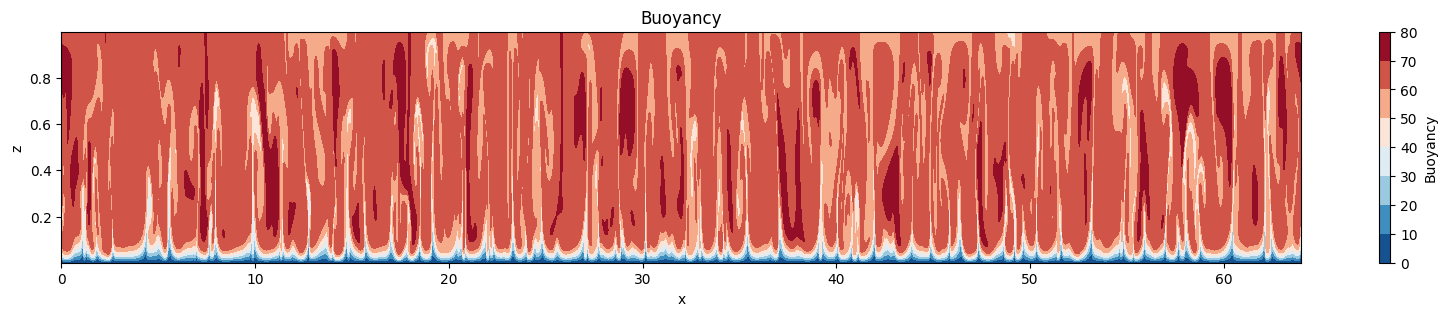

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
import dedalus.public as d3
import logging
logger = logging.getLogger(__name__)
import copy
import h5py
import numpy as np
import matplotlib
import re

import matplotlib.pyplot as plt
from dedalus.extras import plot_tools

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

import os
from os import listdir
N_s2=4/3
file = "/scratch/zb2113/DedalusData/2D/MRBC_2D_RaM_1.0e+06_Pr_1.0e+00_QR_7.0e-02_DH_3.3e-01_Lx_6.4e+01_Nz_128/analysis/analysis_s200.h5"
# file = "/scratch/zb2113/DedalusData/2D/Dry/restart/restart_s2.h5"
with h5py.File(file, mode='r') as file:
    print(list(file.keys()))
    scalekeys=list(file['scales'].keys())
    taskkeys=list(file['tasks'].keys())
    print(scalekeys)
    print(taskkeys)
    #automatic read x y zhash: testing feature
    xhash=scalekeys[-2]
    zhash=scalekeys[-1]
    X=file['scales'][xhash]
    Z=file['scales'][zhash]
    xmesh,zmesh=np.meshgrid(X,Z)
    x=np.array(X)
    z=np.array(Z)
    # print(M[:,:511].shape)
    M = np.transpose(file['tasks']['M'][-1,:,:])
    C = np.transpose(file['tasks']['C'][-1,:,:])
    D = np.transpose(file['tasks']['D'][-1,:,:])
    # uz = np.transpose(file['tasks']['u'][-1,:,:][0])
    # print(uz.shape)
    B = np.maximum(M,D-N_s2*zmesh)
    extraB = B-D+N_s2*zmesh
    extraB = np.maximum(extraB,1e-10)

    plt.figure(figsize=(20,3))
    plt.contourf(x, z , C, cmap='RdBu_r')
    plt.colorbar(label='Buoyancy')
    plt.xlabel('x')
    plt.ylabel('z')
    plt.title('Buoyancy')
    plt.show()
    # plt.savefig(plot_dir+'/C.png', dpi=200, bbox_inches='tight')
    plt.clf()